### Overview

We build a regular 10 km x 10 km grid over the field boundaries extracted in the previous notebook, and select only the grid cells that contain at least one field. This grid will be used in the following notebook to process each cell independently.

### Overview of the Task

We load the field boundaries saved in the previous step and build a grid covering their extent. We use a GeoPandas spatial join on each field's centroid - rather than its full polygon - to assign every field to exactly one grid cell, even when the field's boundary spans more than one cell. We then keep only the populated grid cells and save the result.

### Setup

Determine our runtime environment and connect to Google Drive if needed.

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'output'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

Import all required libraries.

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
from shapely.geometry import box

### Load Field Boundaries

Load the field boundaries saved by the previous notebook.

In [ ]:
fields_filepath = os.path.join(output_folder, 'field_boundaries.gpkg')
fields_gdf = gpd.read_file(fields_filepath)
fields_gdf

Load the selected Admin2 district boundary saved by the previous notebook, so we can visualize it alongside the grid. Falls back to a default boundary hosted in cloud storage if it isn't found locally.

In [ ]:
admin2_filepath = os.path.join(data_folder, 'selected_admin2.gpkg')
if not os.path.exists(admin2_filepath):
    print(f'Admin2 boundary file not found at {admin2_filepath}.',
          'Using default boundary.')
    admin2_filepath = (
        'https://storage.googleapis.com/spatialthoughts-public-data'
        '/python-remote-sensing/selected_admin2.gpkg')

admin2_gdf = gpd.read_file(admin2_filepath)
admin2_gdf

### Create a Grid

We build a regular 10 km x 10 km grid covering the extent of the field boundaries.

Reproject the field boundaries to the local UTM zone so we can define the grid size in meters.

In [ ]:
utm_crs = fields_gdf.estimate_utm_crs()
fields_proj = fields_gdf.to_crs(utm_crs)
admin2_proj = admin2_gdf.to_crs(utm_crs)

Specify the size of each grid cell in meters.

In [ ]:
TILE_SIZE_M = 10000  # 10 km

Build the grid cells using [`shapely.box`](https://shapely.readthedocs.io/en/stable/reference/shapely.box.html) and keep only the cells that intersect the field boundaries.

In [ ]:
minx, miny, maxx, maxy = fields_proj.total_bounds

xs = np.arange(minx, maxx, TILE_SIZE_M)
ys = np.arange(miny, maxy, TILE_SIZE_M)

tiles = [
    box(x, y, x + TILE_SIZE_M, y + TILE_SIZE_M)
    for y in sorted(ys, reverse=True)
    for x in xs
]

grid = gpd.GeoDataFrame(geometry=tiles, crs=utm_crs)
grid = grid[grid.intersects(fields_proj.union_all())].reset_index(drop=True)
grid['tile_id'] = [
    f'tile_{(i // len(ys)) + 1:02d}_{(i % len(ys)) + 1:02d}'
    for i in grid.index
]
print(f'{len(grid)} grid cells intersect the field boundaries')

Visualize the grid overlaid on the field boundaries.

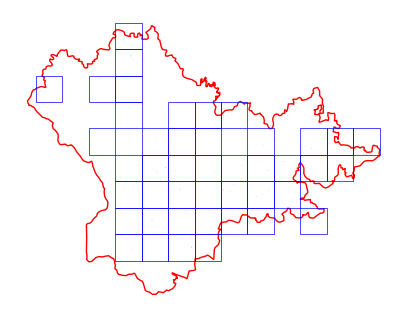

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5, 5)

admin2_proj.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1)
fields_proj.plot(ax=ax, facecolor='#525252', edgecolor='none')
grid.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=0.5)

ax.set_axis_off()
plt.show()

### Assign a Grid ID to Each Field

A field's polygon can span more than one grid cell. To assign each field to a single grid cell, we run the spatial join on the field's centroid instead of its full polygon, using [`gpd.sjoin`](https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin.html).

In [ ]:
field_centroids = fields_proj.copy()
field_centroids['geometry'] = fields_proj.geometry.centroid

joined = gpd.sjoin(
    field_centroids, grid[['tile_id', 'geometry']],
    how='left', predicate='within')
joined = joined[~joined.index.duplicated(keep='first')]

fields_gdf['tile_id'] = joined['tile_id']
fields_gdf

### Save the Results

We save the selected grid cells and the field boundaries as a GeoPackage for use in the next notebook, reprojecting back to EPSG:4326 to match the field boundaries.

In [ ]:
output_filename = 'field_tiling_grid.gpkg'
output_path = os.path.join(output_folder, output_filename)
grid.to_crs('EPSG:4326').to_file(output_path)
print(f'Saved to {output_path}')

Saved to output/field_tiling_grid.gpkg


In [ ]:
output_filename = 'field_boundaries_with_tile_id.gpkg'
output_path = os.path.join(output_folder, output_filename)
fields_gdf.to_file(output_path)
print(f'Saved to {output_path}')